# Tutorial model run for the GeoEnthalpyDelta component for building a small delta fan

Builds a small delta prograding from a west-edge feeder onto a planar,
fixed basement, with a flat sea level, then plots map-view thickness and a
centerline cross-section (bedrock, topography, sea level).

This component implements the two-dimensional finite-volume core of the
enthalpy-based delta model described in Lorenzo-Trueba, Anderson, Bui, and
Voller, *GeoEnthalpy-Delta v1.0: an enthalpy-based model for coupled
subaerial and subaqueous delta evolution with diagnostic moving
boundaries* (manuscript in preparation for *Geoscientific Model
Development*).

## Theory: delta evolution as a moving-boundary problem

Deltas grow (or retreat) by depositing sediment across a basin, and the geomorphic boundaries that define one, and their boundaries are not fixed in advance. They move as part of the solution, the same way a melting front advances in a classical Stefan (phase-change) problem.

`GeoEnthalpyDelta` Component implements the 2D fixed-grid model described in
Lorenzo-Trueba, Anderson, Bui, and Voller, *GeoEnthalpy-Delta v1.0: an enthalpy-based model for coupled subaerial and subaqueous delta evolution with diagnostic moving boundaries* (manuscript in preparation for
*Geoscientific Model Development*), which tracks three such diagnostic
boundaries:

- **ABT** (alluvial–bedrock transition): the upstream limit of finite
  sediment thickness.
- **SH** (shoreline): the contour where the reconstructed land surface
  crosses sea level.
- **TOE**: the offshore limit of finite sediment thickness.

Rather than tracking these boundaries explicitly, the model
evolves a single conserved field, sediment thickness $H$, on a **fixed**
grid, and *diagnoses* the boundaries afterward from $H$ and the
reconstructed surface. That fixed-grid, diagnose-it-afterward strategy is
the `enthalpy` in the name: it is borrowed from phase-change (Stefan)
problems in heat transfer, applied here to sediment mass instead of
thermal energy. The next few cells work through the governing equations,
transport closure, and numerical scheme before running the model; 
> skip ahead to **Grid setup** if you just want to run the example.

### Governing equations

The primary state variable is the **sediment thickness above the fixed basement**, $H(x, y, t)$ ~ `sediment__thickness` field. 

Given the prescribed, non-erodible `basement__elevation` $E(x, y)$, the
reconstructed land-surface elevation (`topographic__elevation`) is

$$
\eta(x, y, t) = E(x, y) + H(x, y, t).
$$

Sediment mass is conserved in flux form:

$$
\frac{\partial H}{\partial t} = -\nabla \cdot \mathbf{q},
\qquad \mathbf{q} = (q_x, q_y),
$$

where $\mathbf{q}$ is the depth-integrated sediment flux. Because the
basement never changes, this is equivalent to evolving the land surface
directly, but writing it in terms of $H$ lets the model use $H = 0$ to
mean "no sediment yet," including at cells the delta hasn't reached —
there's no need to track a moving computational domain.

At every node, sea level $Z(t)$ splits the domain into two local transport
regimes, evaluated from the reconstructed surface:

$$
k(x,y,t) =
\begin{cases}
\text{topset}, & \eta(x,y,t) \ge Z(t) \\
\text{foreset}, & \eta(x,y,t) < Z(t)
\end{cases}
$$

so a node switches from topset to foreset (or back) automatically as $H$,
$\eta$, or $Z(t)$ evolve — the shoreline is simply wherever this switch
currently falls, rather than a boundary the code has to move by hand.

### Critical slopes for sediment transport

Sediment is redistributed by a nonlinear diffusive flux driven by the
local slope of $\eta$, with a critical slope (threshold) below which no
transport occurs. The down-system (grid-x, feeder-to-basin) flux is
directed only seaward:

$$
q_x = D_k^x \max\!\left(-\frac{\partial \eta}{\partial x} - C_k^x,\; 0\right),
$$

while the lateral (grid-y) flux can act in either direction, down the
local cross-slope:

$$
q_y = -D_k^y \operatorname{sgn}\!\left(\frac{\partial \eta}{\partial y}\right)
\max\!\left(\left|\frac{\partial \eta}{\partial y}\right| - C_k^y,\; 0\right).
$$

The subscript $k \in \{\text{top}, \text{fore}\}$ means the diffusivity
$D_k$ and threshold slope $C_k$ switch depending on whether the *donor*
cell (the one sediment is leaving) is currently topset or foreset — so the
same flux law governs both the subaerial delta plain and the submerged
foreset, just with different mobility parameters in each regime.

Four independent parameter pairs therefore control transport: a
down-system and a lateral diffusivity/threshold pair for the topset, and
another pair for the foreset. 
In the component these are the parameters:
- `topset_diffusivity_x`, 
- `topset_diffusivity_y`, 
- `foreset_diffusivity_x`,
- `foreset_diffusivity_y`, 
- `topset_threshold_x`, 
- `topset_threshold_y`,
- `foreset_threshold_x`,
- `foreset_threshold_y`

### Numerical Step `run_one_step`

`GeoEnthalpyDelta` solves the equations above with an explicit, conservative
finite-volume update on the fixed `RasterModelGrid`, in three passes per time step (see `_enthalpy_diffusion_step` in `geoenthalpy_delta.py`):

1. **Candidate lateral fluxes** are computed from the cross-slope of $\eta$ at every internal grid-y face, using the donor cell's topset/foreset regime and its threshold/diffusivity.
2. **Lateral positivity limiter**: because sediment can leave a cell in both the $+y$ and $-y$ directions within the same step, candidate lateral fluxes are scaled down (never up) so that no cell can export more sediment than it currently holds.
3. **Downstream fluxes**, swept from the feeder (west/upstream edge) toward the basin (east/downstream edge): each cell's outgoing down-system flux is capped by both its transport capacity *and* the sediment actually available to it once its incoming upstream and already-limited lateral fluxes are accounted for.

This ordering guarantees $H \ge 0$ everywhere without an iterative solve,
at the cost of requiring an explicit, diffusion-type stable time step
which is why the tutorial calls `esd.calc_stable_time_step()` rather than
picking `dt` by hand. 

> If the stable time step returned by `calc_stable_time_step()` is smaller than the time step you want to advance by in your own project, subcycle: run several inner steps per outer step. 
> Compute the number of inner steps as `n_inner = ceil(outer_dt / calculated_dt)`, then call run_one_step that many times, each with `dt = outer_dt / n_inner` which is guaranteed to be <= `calculated_dt`.

Sediment enters the grid only through the feeder cells along the west edge; every other edge (including the downstream edge) is a no-flux boundary, so a run should be stopped, or the domain made larger, before the deposit reaches the lateral or downstream edges.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from landlab import RasterModelGrid
from landlab.components import GeoEnthalpyDelta

In [2]:
help(GeoEnthalpyDelta)

Help on class GeoEnthalpyDelta in module landlab.components.geoenthalpy_delta.geoenthalpy_delta:

class GeoEnthalpyDelta(landlab.core.model_component.Component)
 |  GeoEnthalpyDelta(
 |      grid,
 |      sediment_flux=0.5,
 |      feeder_width=1.0,
 |      feeder_y_center=None,
 |      sea_level_start=0.0,
 |      sea_level_rise_rate=0.0,
 |      topset_threshold_x=0.0,
 |      topset_threshold_y=0.0,
 |      foreset_threshold_x=2.0,
 |      foreset_threshold_y=2.0,
 |      topset_diffusivity_x=1.0,
 |      topset_diffusivity_y=1.0,
 |      foreset_diffusivity_x=1.0,
 |      foreset_diffusivity_y=1.0,
 |      cfl=0.4
 |  )
 |
 |  Simulate 2D sediment diffusion, transport, and deposition using an
 |  enthalpy formulation of a topset/foreset delta model.
 |
 |  This component is a structured Landlab wrapper around the core physics
 |  of a manuscript on 2D GeoEnthalpy-Delta modeling.
 |
 |  Sediment is supplied through a feeder with assigned width and is transported as a nonlinear,
 |  

## Grid setup

The basement is the fixed, non-erodible surface $E(x,y)$ of Eq. (1) in the
paper, $E(x) = -\beta x$, with the basement slope $\beta$ absorbed into
the nondimensionalization so that the beta-normalized form used by the
code is simply $E(x) = -x$ (Sect. 4.3). $x$ increases down-system, from
the feeder toward the basin; $y$ is the lateral, cross-system direction.
`basement__elevation` never changes during a run — only
`sediment__thickness` evolves on top of it.

In [3]:
nrows, ncols = 50, 50
dx = dy = 0.2
# xy_spacing also accepts a (dx, dy) tuple if you need dx != dy; a scalar
# here just means dx == dy.
grid = RasterModelGrid((nrows, ncols), xy_spacing=dx)

x = grid.x_of_node.reshape(grid.shape)
bedrock = grid.add_zeros("basement__elevation", at="node")
bedrock[:] = (-x).reshape(-1)  # planar, non-erodible basement E(x) = -x

Component calling

The keyword arguments below set the nondimensional, beta-normalized
parameters of Sect. 4.3 of the paper (the component is unit-agnostic
`_unit_agnostic = True` no physical units attach to any of them):

| keyword | paper symbol | meaning |
|---|---|---|
| `sediment_flux` | $Q_{\mathrm{in}}$ | total sediment input rate through the feeder |
| `feeder_width` | $w_f$ | width of the upstream feeder |
| `sea_level_start` | $Z(0)$ | sea level at $t=0$ |
| `sea_level_rise_rate` | $\dot Z$ | constant rate of sea-level change |
| `topset_threshold_x` | $C_{\mathrm{top}}^x$ | down-system critical slope, topset |
| `topset_threshold_y` | $C_{\mathrm{top}}^y$ | lateral critical slope, topset |
| `foreset_threshold_x` | $C_{\mathrm{fore}}^x$ | down-system critical slope, foreset |
| `foreset_threshold_y` | $C_{\mathrm{fore}}^y$ | lateral critical slope, foreset |
| `topset_diffusivity_x` | $D_{\mathrm{top}}^x$ | down-system transport coefficient, topset |
| `topset_diffusivity_y` | $D_{\mathrm{top}}^y$ | lateral transport coefficient, topset |
| `foreset_diffusivity_x` | $D_{\mathrm{fore}}^x$ | down-system transport coefficient, foreset |
| `foreset_diffusivity_y` | $D_{\mathrm{fore}}^y$ | lateral transport coefficient, foreset |

A finite (non-vertical) foreset requires $C_{\mathrm{fore}}^x$ to exceed
the beta-normalized basement slope of 1 (Sect. 5.2 of the paper); the
`foreset_threshold_x=2.0` used below satisfies that, which is why the
deposit develops a genuine subaqueous toe rather than an abrupt drop-off.

In [4]:
sea_level = -5.0
esd = GeoEnthalpyDelta(
    grid,
    sediment_flux=0.5,
    feeder_width=1.0,
    sea_level_start=sea_level,
    sea_level_rise_rate=0.0,
    topset_threshold_x=0.25,
    topset_threshold_y=0.1,
    foreset_threshold_x=2.0,
    foreset_threshold_y=2.0,
    topset_diffusivity_x=1.0,
    topset_diffusivity_y=1.0,
    foreset_diffusivity_x=1.0,
    foreset_diffusivity_y=1.0,
)

dt = esd.calc_stable_time_step()
nsteps = 5500
print(f"dt = {dt:.5g}, running {nsteps} steps (t_end = {nsteps * dt:.3g}) ...")

dt = 0.004, running 5500 steps (t_end = 22) ...


This will take a while. You should see `done in #.# s` printed once the run has completed.

In [5]:
t0 = time.time()
volume_history = []
time_history = []
for step in range(nsteps):
    esd.run_one_step(dt)
    if step % 25 == 0:
        vol = np.sum(grid.at_node["sediment__thickness"]) * dx * dy
        volume_history.append(vol)
        time_history.append(esd.time_elapsed)
print(f"done in {time.time() - t0:.2f} s")

done in 21.32 s


## Mass balance

The finite-volume update conserves sediment exactly except for the feeder
input and the positivity clip at $H=0$, so the total stored volume

$$
V(t) = \sum_{i,j} H_{i,j}(t)\, \Delta x\, \Delta y
$$

should track the cumulative imposed input $V_{\mathrm{in}}(t) =
Q_{\mathrm{in}}\, t$ (Eqs. 56-58 of the paper) up to floating-point
roundoff. 

If the fan reaches those edges before the run ends, sediment piles up against them and this check starts to fail; that's a sign to enlarge the grid or shorten the run, not evidence of a conservation bug.

> If you rerun the loop, the mass balance wont be able to keep track of the new loop. The massbalance from that run could result in a mismatch 

In [6]:
expected_volume = 0.5 * nsteps * dt
final_volume = np.sum(grid.at_node["sediment__thickness"]) * dx * dy
np.isclose(final_volume, expected_volume, rtol=1e-6)


np.True_

## The three fields this component exposes

`GeoEnthalpyDelta` reads one field you supply (`basement__elevation`,
fixed) and writes two (`sediment__thickness` $H$, and
`topographic__elevation` $\eta = E + H$ from Eq. 2). Together they show,
node by node, how much bare basement lies below (1), how thick the mobile
deposit is (2), and what the combined land surface looks like relative to
sea level (3) — the same fields the paper's shoreline diagnostic
$\eta(x,y,t) = Z(t)$ (Sect. 3.3) would be computed from.

1. `basement__elevation`

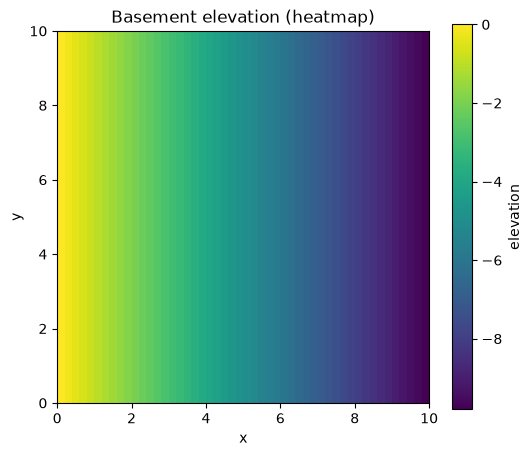

In [7]:
basement = grid.at_node["basement__elevation"].reshape(grid.shape)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(basement, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="viridis", aspect="equal")
ax.set_title("Basement elevation (heatmap)")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="elevation")
plt.show()

2. `grid.at_node["sediment__thickness"]` — the prognostic variable $H$ that the model actually integrates forward in time each step.

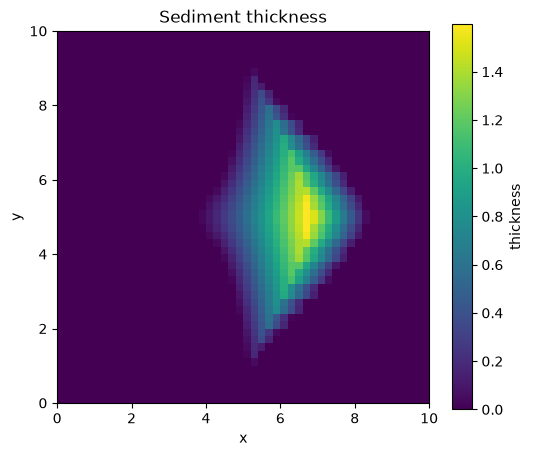

In [8]:
Hthickness = grid.at_node["sediment__thickness"].reshape(grid.shape)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Hthickness, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="viridis", aspect="equal")
ax.set_title("Sediment thickness")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="thickness")
plt.show()

3. `grid.at_node["topographic__elevation"]` — the reconstructed surface $\eta = E + H$; compare it to the sea level line in the cross-section below to see where the shoreline currently sits.

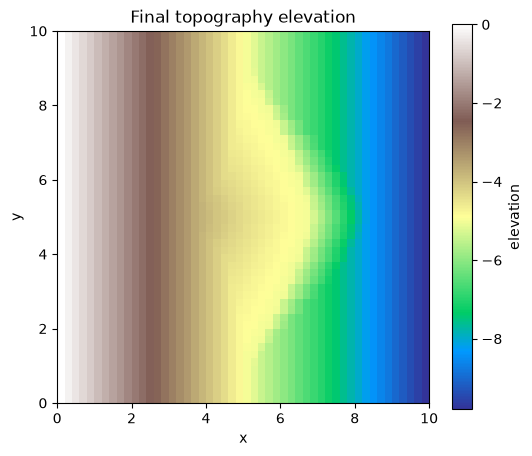

In [9]:
final_topography = grid.at_node["topographic__elevation"].reshape(grid.shape)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(final_topography, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="terrain", aspect="equal")
ax.set_title("Final topography elevation")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="elevation")
plt.show()

## Comprehensive plots

The panels below combine the same fields into one figure: a map view of
$H$, a centerline cross-section comparing the reconstructed surface
$\eta$ against the fixed basement and current sea level, and the running
mass-balance check from above.

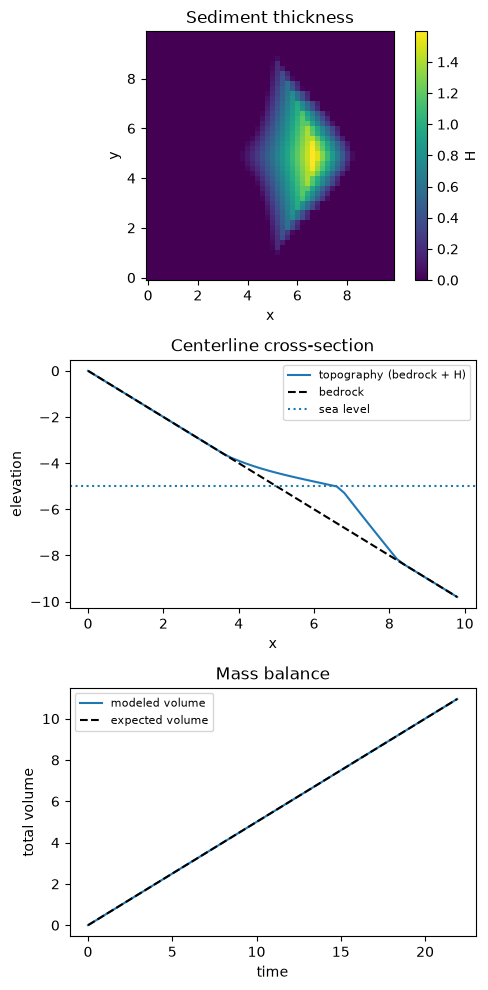

In [10]:
H = Hthickness
eta = final_topography
final_sea_level = sea_level + esd.sea_level_rise_rate * esd.time_elapsed
X = grid.x_of_node.reshape(grid.shape)
Y = grid.y_of_node.reshape(grid.shape)
j_mid = nrows // 2

fig, axes = plt.subplots(3, 1, figsize=(5, 10))

im = axes[0].pcolormesh(X, Y, H, shading="auto", cmap="viridis")
axes[0].set_title("Sediment thickness")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
fig.colorbar(im, ax=axes[0], label="H")

axes[1].plot(X[j_mid], eta[j_mid], label="topography (bedrock + H)")
axes[1].plot(X[j_mid], basement[j_mid],
             "k--", label="bedrock")
axes[1].axhline(final_sea_level,color="tab:blue",linestyle=":",label="sea level")
axes[1].set_title("Centerline cross-section")
axes[1].set_xlabel("x")
axes[1].set_ylabel("elevation")
axes[1].legend(fontsize=8)

axes[2].plot(time_history, volume_history, label="modeled volume")
axes[2].plot(time_history, [0.5 * t for t in time_history], "k--", label="expected volume")
axes[2].set_title("Mass balance")
axes[2].set_xlabel("time")
axes[2].set_ylabel("total volume")
axes[2].legend(fontsize=8)

fig.tight_layout()